# CNN Image Classification with CIFAR-10

## Business Objective

This project explores multi-class image classification using a Convolutional Neural Network built with TensorFlow and Keras.

The objective is to train a model capable of recognising ten different object categories in CIFAR-10 images, evaluate how well the network generalises to unseen data, and analyse where classification errors occur.

The project goes beyond overall accuracy by examining training behaviour, class-level performance, confusion patterns and examples of both correct and incorrect predictions.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 53s 0us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


In [3]:
print("Image data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

train_class_counts = pd.Series(
    y_train.flatten()
).value_counts().sort_index()

test_class_counts = pd.Series(
    y_test.flatten()
).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Class": class_names,
    "Train": train_class_counts.values,
    "Test": test_class_counts.values
})

class_distribution

Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


,Class,Train,Test
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


## Dataset Overview

CIFAR-10 contains 60,000 RGB colour images distributed evenly across ten object classes.

The dataset is already divided into:

- 50,000 training images
- 10,000 test images
- 10 balanced classes
- 5,000 training images per class
- 1,000 test images per class

Each image has a resolution of 32 × 32 pixels with three RGB channels.

Pixel values are stored as unsigned 8-bit integers ranging from 0 to 255. Before model training, these values will be normalised to the 0–1 range to provide a more suitable numerical scale for neural network optimisation.

In [4]:
# Normalise pixel values to the 0–1 range
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten labels for easier evaluation later
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training pixel range:", x_train.min(), "to", x_train.max())
print("Test pixel range:", x_test.min(), "to", x_test.max())
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training pixel range: 0.0 to 1.0
Test pixel range: 0.0 to 1.0
Training labels shape: (50000,)
Test labels shape: (10000,)


## Visual Inspection

Before building the neural network, a sample image from each CIFAR-10 class is inspected.

Because the images have a resolution of only 32 × 32 pixels, object details are limited. This makes the classification problem more challenging, particularly for visually similar categories.

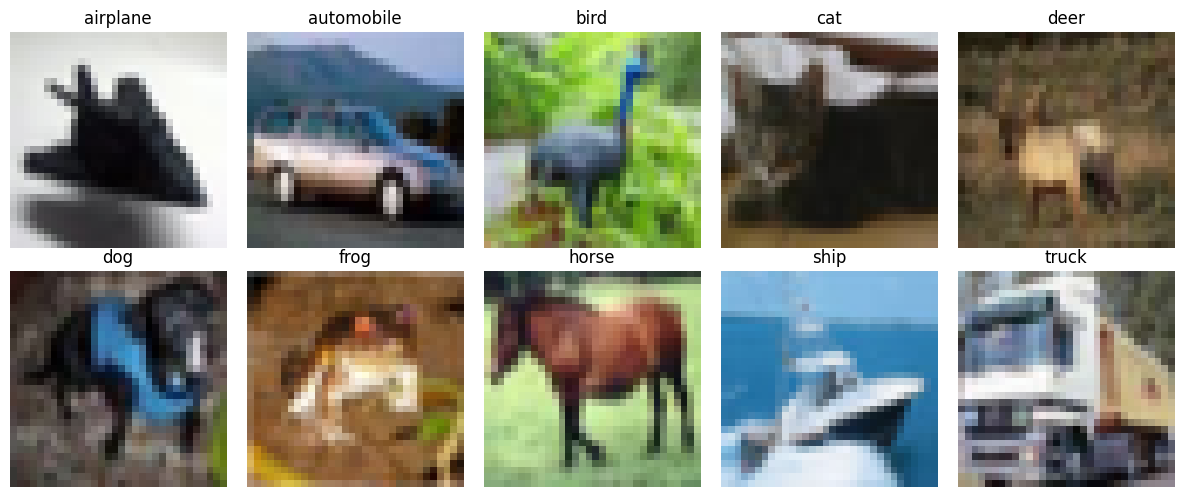

In [5]:
# Display one example from each class
plt.figure(figsize=(12, 5))

for class_id, class_name in enumerate(class_names):
    image_index = np.where(y_train == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[image_index])
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Baseline CNN Architecture

A baseline Convolutional Neural Network is built to establish an initial classification performance.

The architecture progressively extracts visual features through convolution and pooling layers before using fully connected layers for final classification.

The model will serve as a baseline for evaluating training behaviour, generalisation and class-level performance.

In [6]:
# Build baseline CNN
baseline_model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),

    keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(
        128,
        activation="relu"
    ),

    keras.layers.Dense(
        10,
        activation="softmax"
    )
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Baseline Architecture

The baseline CNN contains three convolutional blocks with progressively increasing feature depth:

- 32 convolutional filters
- 64 convolutional filters
- 128 convolutional filters

Each convolutional layer is followed by max pooling, reducing the spatial dimensions while retaining the strongest learned activations.

After the final pooling layer, the 4 × 4 × 128 feature representation is flattened and passed through a 128-unit dense layer before the final 10-class softmax output.

The model contains 356,810 trainable parameters.

This deliberately simple architecture establishes a baseline before introducing techniques intended to improve generalisation.

In [7]:
# Compile the baseline CNN
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline model compiled successfully.")

Baseline model compiled successfully.


## Training Strategy

The original training set is divided into separate training and validation subsets.

The validation data is used to monitor learning behaviour and detect overfitting during training, while the official CIFAR-10 test set remains untouched until the final model evaluation.

A stratified split is used to preserve the balanced class distribution.

In [8]:
from sklearn.model_selection import train_test_split

# Create training and validation subsets
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training subset:", x_train_final.shape, y_train_final.shape)
print("Validation subset:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

print("\nTraining samples per class:")
print(pd.Series(y_train_final).value_counts().sort_index().tolist())

print("\nValidation samples per class:")
print(pd.Series(y_val).value_counts().sort_index().tolist())

Training subset: (40000, 32, 32, 3) (40000,)
Validation subset: (10000, 32, 32, 3) (10000,)
Test set: (10000, 32, 32, 3) (10000,)

Training samples per class:
[4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000]

Validation samples per class:
[1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


In [9]:
# Stop training when validation performance stops improving
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# Train the baseline CNN
baseline_history = baseline_model.fit(
    x_train_final,
    y_train_final,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 91ms/step - accuracy: 0.4439 - loss: 1.5320 - val_accuracy: 0.5789 - val_loss: 1.1984
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.6155 - loss: 1.0833 - val_accuracy: 0.6630 - val_loss: 0.9646
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.6881 - loss: 0.8964 - val_accuracy: 0.6634 - val_loss: 0.9847
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.7273 - loss: 0.7859 - val_accuracy: 0.7029 - val_loss: 0.8716
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.7540 - loss: 0.6975 - val_accuracy: 0.7064 - val_loss: 0.8578
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7847 - loss: 0.6212 - val_accuracy: 0.7269 - val_loss: 0.8072
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.8085 - loss: 0.5492 - val_accuracy: 0.7237 - val_loss: 0.8361
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.8294 - loss: 0.4826 - 

In [10]:
# Identify the best baseline epoch
best_epoch = np.argmin(baseline_history.history["val_loss"]) + 1

print("Epochs completed:", len(baseline_history.history["loss"]))
print("Best epoch by validation loss:", best_epoch)

print(
    "Training accuracy at best epoch:",
    round(baseline_history.history["accuracy"][best_epoch - 1], 4)
)

print(
    "Validation accuracy at best epoch:",
    round(baseline_history.history["val_accuracy"][best_epoch - 1], 4)
)

print(
    "Training loss at best epoch:",
    round(baseline_history.history["loss"][best_epoch - 1], 4)
)

print(
    "Validation loss at best epoch:",
    round(baseline_history.history["val_loss"][best_epoch - 1], 4)
)

Epochs completed: 10
Best epoch by validation loss: 6
Training accuracy at best epoch: 0.7847
Validation accuracy at best epoch: 0.7269
Training loss at best epoch: 0.6212
Validation loss at best epoch: 0.8072


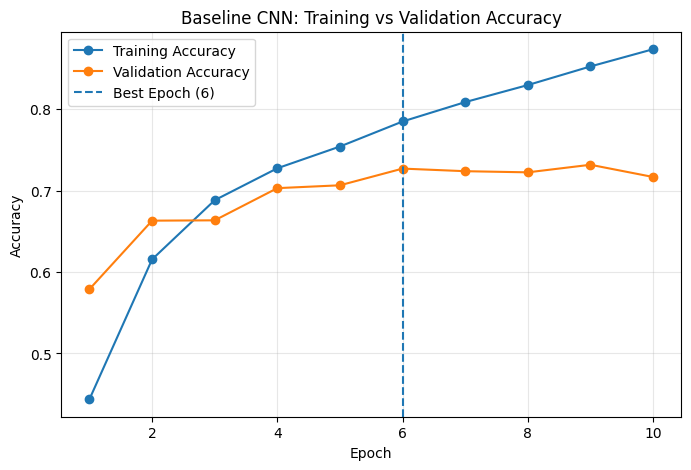

In [11]:
# Plot baseline learning curves
epochs_range = range(1, len(baseline_history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    baseline_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    epochs_range,
    baseline_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN: Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

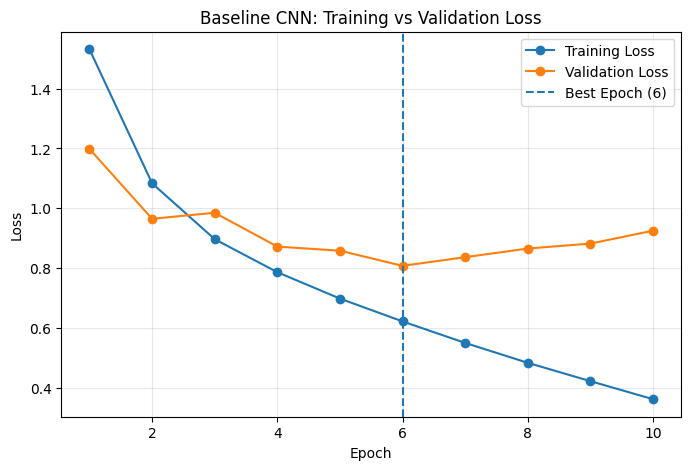

In [12]:
# Plot baseline loss curves
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    baseline_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    baseline_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Evaluate the restored baseline model on the untouched test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Baseline test loss:", round(baseline_test_loss, 4))
print("Baseline test accuracy:", round(baseline_test_accuracy, 4))

Baseline test loss: 0.8175
Baseline test accuracy: 0.7257


In [14]:
from sklearn.metrics import classification_report

# Generate baseline predictions on the test set
baseline_probabilities = baseline_model.predict(
    x_test,
    verbose=0
)

baseline_predictions = np.argmax(
    baseline_probabilities,
    axis=1
)

# Class-level performance
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.7628    0.7910    0.7766      1000
  automobile     0.8514    0.8420    0.8467      1000
        bird     0.5741    0.6740    0.6201      1000
         cat     0.6144    0.4620    0.5274      1000
        deer     0.6584    0.6630    0.6607      1000
         dog     0.6257    0.6670    0.6457      1000
        frog     0.6987    0.8510    0.7674      1000
       horse     0.8343    0.7000    0.7613      1000
        ship     0.8166    0.8460    0.8310      1000
       truck     0.8628    0.7610    0.8087      1000

    accuracy                         0.7257     10000
   macro avg     0.7299    0.7257    0.7246     10000
weighted avg     0.7299    0.7257    0.7246     10000



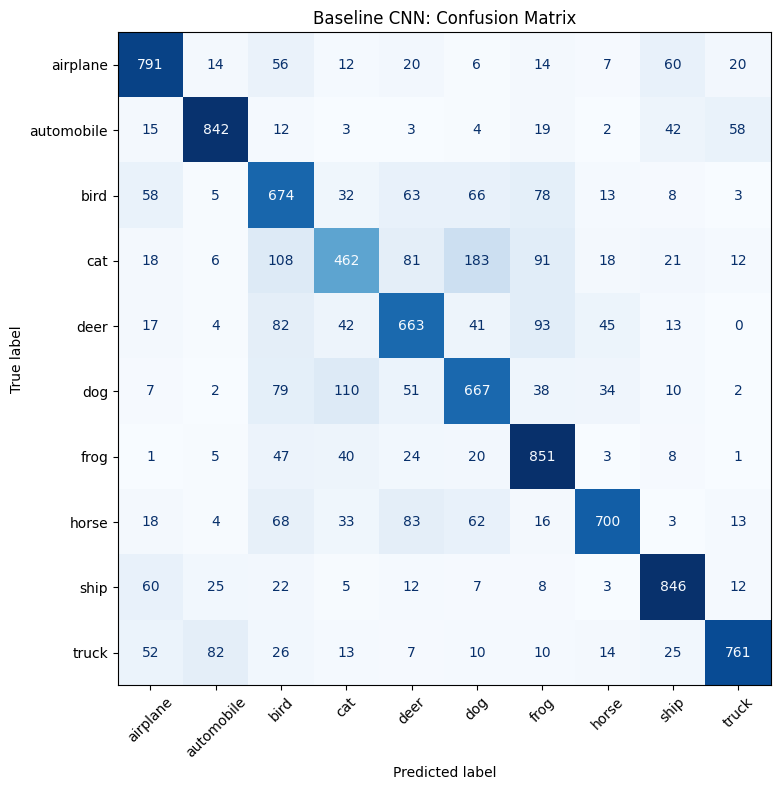

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Baseline confusion matrix
baseline_cm = confusion_matrix(
    y_test,
    baseline_predictions
)

fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=class_names
)

display.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

plt.title("Baseline CNN: Confusion Matrix")
plt.tight_layout()
plt.show()

## Baseline Error Analysis

The baseline CNN achieved a test accuracy of 72.57% and a macro F1-score of 0.7246.

Performance varied considerably across classes. Automobile, ship and truck achieved the strongest F1-scores, while cat, bird and dog were substantially more difficult to classify.

The confusion matrix reveals several important error patterns:

- 183 cat images were classified as dogs.
- 110 dog images were classified as cats.
- 108 cat images were classified as birds.
- 93 deer images were classified as frogs.
- 83 horse images were classified as deer.
- 82 trucks were classified as automobiles.
- Airplanes and ships were confused in both directions, with 60 errors each.

These results suggest that the baseline model struggles particularly with visually similar categories. The widening gap between training and validation performance also indicates overfitting.

The next model will therefore focus on improving generalisation through a stronger convolutional architecture, regularisation and data augmentation.

In [16]:
# Check available hardware
gpus = tf.config.list_physical_devices("GPU")

print("GPU available:", len(gpus) > 0)
print("GPU devices:", gpus)

GPU available: False
GPU devices: []


## Improved CNN Strategy

The baseline analysis identified two main limitations: increasing overfitting after the sixth epoch and weaker performance on visually similar animal classes.

The improved model therefore introduces:

- data augmentation to expose the network to additional variations of the training images,
- deeper feature extraction using multiple convolutional layers,
- batch normalisation to stabilise training,
- dropout regularisation to reduce overfitting,
- and global average pooling to reduce the number of parameters before classification.

The objective is not simply to increase training accuracy, but to improve generalisation on unseen images.

In [17]:
# Data augmentation for the improved CNN
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip(
        "horizontal",
        seed=42
    ),
    keras.layers.RandomRotation(
        0.05,
        seed=42
    ),
    keras.layers.RandomZoom(
        0.10,
        seed=42
    )
], name="data_augmentation")

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


In [18]:
# Build the improved CNN
keras.utils.set_random_seed(42)

improved_model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    # Convolutional block 1
    keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),

    keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),

    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.20),

    # Convolutional block 2
    keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),

    keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),

    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.30),

    # Convolutional block 3
    keras.layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.40),

    keras.layers.Dense(10, activation="softmax")
])

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             

 Total params: 141,674 (553.41 KB)

 Trainable params: 141,034 (550.91 KB)

 Non-trainable params: 640 (2.50 KB)

In [19]:
# Compile the improved CNN
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved model compiled successfully.")

Improved model compiled successfully.


In [20]:
# Training callbacks for the improved CNN
improved_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

# Train the improved CNN
improved_history = improved_model.fit(
    x_train_final,
    y_train_final,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[
        improved_early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 265ms/step - accuracy: 0.4159 - loss: 1.5818 - val_accuracy: 0.4234 - val_loss: 1.6489 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 267ms/step - accuracy: 0.5303 - loss: 1.3036 - val_accuracy: 0.5030 - val_loss: 1.3570 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 274ms/step - accuracy: 0.5717 - loss: 1.1973 - val_accuracy: 0.5364 - val_loss: 1.3050 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 266ms/step - accuracy: 0.6032 - loss: 1.1161 - val_accuracy: 0.5891 - val_loss: 1.1151 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 281ms/step - accuracy: 0.6231 - loss: 1.0647 - val_accuracy: 0.5796 - val_loss: 1.1769 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 283ms/step - accuracy: 0.6396 - loss: 1.0202 - val_accuracy: 0.6238 - val_loss: 1.0354 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 204s 286ms/step - accura

In [21]:
# Identify the best epoch of the improved CNN
improved_best_epoch = np.argmin(
    improved_history.history["val_loss"]
) + 1

best_val_accuracy_epoch = np.argmax(
    improved_history.history["val_accuracy"]
) + 1

print("Epochs completed:", len(improved_history.history["loss"]))
print("Best epoch by validation loss:", improved_best_epoch)

print(
    "Training accuracy at best epoch:",
    round(improved_history.history["accuracy"][improved_best_epoch - 1], 4)
)

print(
    "Validation accuracy at best epoch:",
    round(improved_history.history["val_accuracy"][improved_best_epoch - 1], 4)
)

print(
    "Training loss at best epoch:",
    round(improved_history.history["loss"][improved_best_epoch - 1], 4)
)

print(
    "Validation loss at best epoch:",
    round(improved_history.history["val_loss"][improved_best_epoch - 1], 4)
)

print(
    "Highest validation accuracy:",
    round(max(improved_history.history["val_accuracy"]), 4),
    "at epoch",
    best_val_accuracy_epoch
)

Epochs completed: 30
Best epoch by validation loss: 29
Training accuracy at best epoch: 0.7522
Validation accuracy at best epoch: 0.7697
Training loss at best epoch: 0.7159
Validation loss at best epoch: 0.6561
Highest validation accuracy: 0.7697 at epoch 29


In [22]:
# Evaluate the improved CNN on the untouched test set
improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Improved test loss:", round(improved_test_loss, 4))
print("Improved test accuracy:", round(improved_test_accuracy, 4))

print(
    "Accuracy improvement over baseline:",
    round((improved_test_accuracy - baseline_test_accuracy) * 100, 2),
    "percentage points"
)

Improved test loss: 0.6768
Improved test accuracy: 0.7658
Accuracy improvement over baseline: 4.01 percentage points


In [23]:
# Generate predictions from the improved CNN
improved_probabilities = improved_model.predict(
    x_test,
    verbose=0
)

improved_predictions = np.argmax(
    improved_probabilities,
    axis=1
)

# Class-level performance
print(
    classification_report(
        y_test,
        improved_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.7788    0.7780    0.7784      1000
  automobile     0.9086    0.8950    0.9018      1000
        bird     0.7063    0.6230    0.6621      1000
         cat     0.6798    0.5350    0.5988      1000
        deer     0.7180    0.7230    0.7205      1000
         dog     0.7488    0.6260    0.6819      1000
        frog     0.6066    0.9050    0.7263      1000
       horse     0.8468    0.7960    0.8206      1000
        ship     0.8596    0.8880    0.8736      1000
       truck     0.8556    0.8890    0.8720      1000

    accuracy                         0.7658     10000
   macro avg     0.7709    0.7658    0.7636     10000
weighted avg     0.7709    0.7658    0.7636     10000



In [24]:
# Compare class-level F1 scores between both models
from sklearn.metrics import classification_report

baseline_report = classification_report(
    y_test,
    baseline_predictions,
    target_names=class_names,
    output_dict=True
)

improved_report = classification_report(
    y_test,
    improved_predictions,
    target_names=class_names,
    output_dict=True
)

class_comparison = pd.DataFrame({
    "Class": class_names,
    "Baseline F1": [
        baseline_report[class_name]["f1-score"]
        for class_name in class_names
    ],
    "Improved F1": [
        improved_report[class_name]["f1-score"]
        for class_name in class_names
    ]
})

class_comparison["F1 Change"] = (
    class_comparison["Improved F1"]
    - class_comparison["Baseline F1"]
)

class_comparison.round(4)

,Class,Baseline F1,Improved F1,F1 Change
0,airplane,0.7766,0.7784,0.0018
1,automobile,0.8467,0.9018,0.0551
2,bird,0.6201,0.6621,0.0420
3,cat,0.5274,0.5988,0.0714
4,deer,0.6607,0.7205,0.0598
5,dog,0.6457,0.6819,0.0362
6,frog,0.7674,0.7263,-0.0410
7,horse,0.7613,0.8206,0.0593
8,ship,0.8310,0.8736,0.0425
9,truck,0.8087,0.8720,0.0633


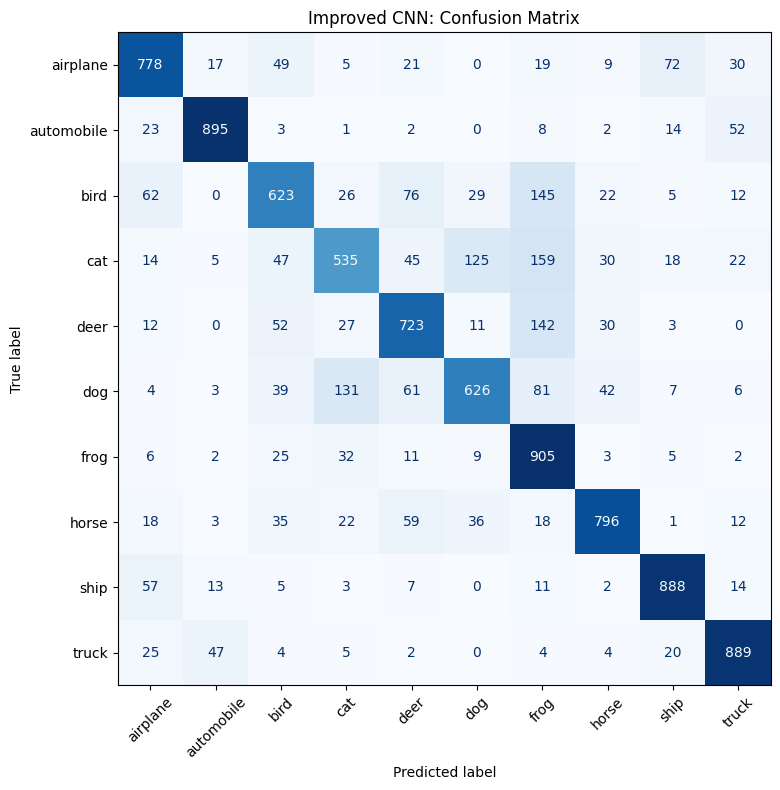

In [25]:
# Improved CNN confusion matrix
improved_cm = confusion_matrix(
    y_test,
    improved_predictions
)

fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=improved_cm,
    display_labels=class_names
)

display.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

plt.title("Improved CNN: Confusion Matrix")
plt.tight_layout()
plt.show()

## Improved Model Error Analysis

The improved CNN increased test accuracy from 72.57% to 76.58%, with improvements in F1-score across nine of the ten CIFAR-10 classes.

Several important baseline confusions were reduced:

- cat → dog decreased from 183 to 125 cases,
- cat → bird decreased from 108 to 47,
- horse → deer decreased from 83 to 59,
- truck → automobile decreased from 82 to 47.

The main exception was the frog class. Frog recall increased substantially to 90.50%, but precision fell to 60.66%.

The confusion matrix shows that the improved model predicts the frog class too frequently, including:

- 145 bird images,
- 159 cat images,
- 142 deer images.

This illustrates an important trade-off: higher recall for one class can come at the cost of lower precision when the model becomes overly willing to assign that label.

Overall, the improved architecture generalises better than the baseline, but class-level error analysis reveals that aggregate accuracy alone does not capture all model behaviour.

In [26]:
# Compare overall performance
comparison_metrics = pd.DataFrame({
    "Model": ["Baseline CNN", "Improved CNN"],
    "Test Accuracy": [
        baseline_test_accuracy,
        improved_test_accuracy
    ],
    "Macro F1": [
        baseline_report["macro avg"]["f1-score"],
        improved_report["macro avg"]["f1-score"]
    ]
})

comparison_metrics

,Model,Test Accuracy,Macro F1
0,Baseline CNN,0.7257,0.724552
1,Improved CNN,0.7658,0.763590


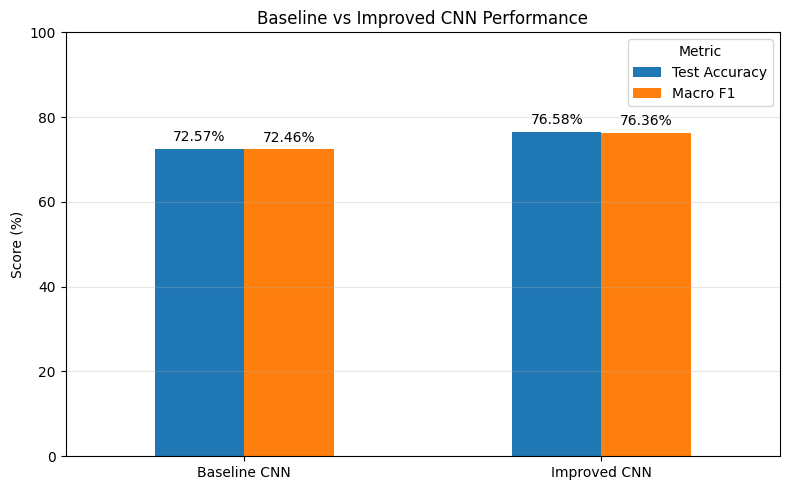

In [27]:
# Visual comparison of overall model performance
comparison_plot = comparison_metrics.copy()

comparison_plot["Test Accuracy"] *= 100
comparison_plot["Macro F1"] *= 100

ax = comparison_plot.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Score (%)")
plt.xlabel("")
plt.title("Baseline vs Improved CNN Performance")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

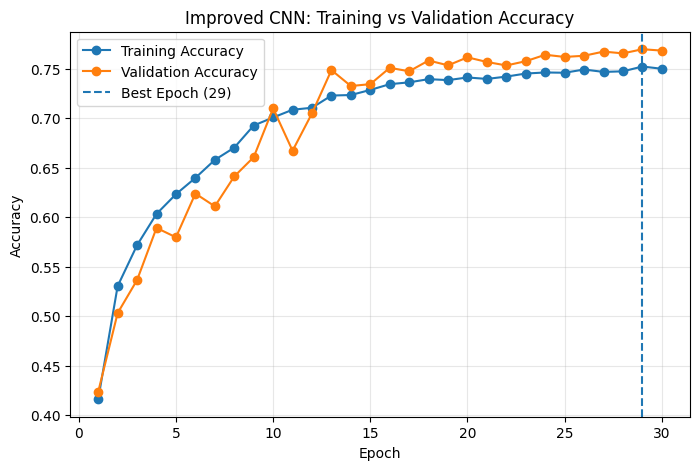

In [28]:
# Plot improved CNN accuracy curves
improved_epochs = range(
    1,
    len(improved_history.history["accuracy"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    improved_epochs,
    improved_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    improved_epochs,
    improved_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    improved_best_epoch,
    linestyle="--",
    label=f"Best Epoch ({improved_best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN: Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

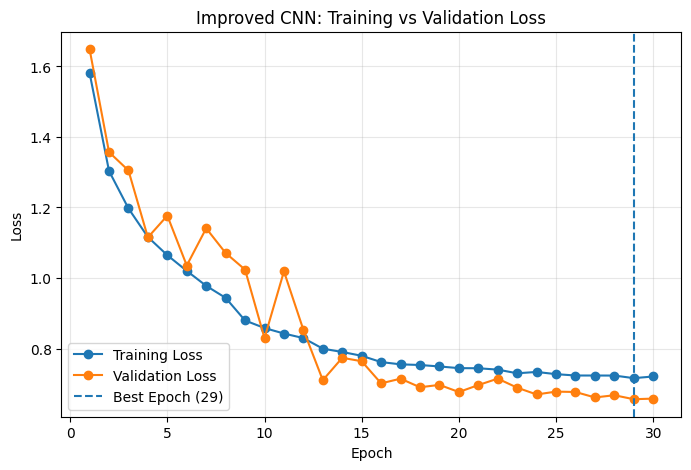

In [29]:
# Plot improved CNN loss curves
plt.figure(figsize=(8, 5))

plt.plot(
    improved_epochs,
    improved_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    improved_epochs,
    improved_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    improved_best_epoch,
    linestyle="--",
    label=f"Best Epoch ({improved_best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CNN: Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Training Behaviour

The improved CNN shows substantially better generalisation behaviour than the baseline model.

In the baseline CNN, training loss continued to decrease after epoch 6 while validation loss increased, providing clear evidence of overfitting.

The improved architecture behaves differently:

- training and validation loss decrease together across most of the training process,
- validation performance continues improving until epoch 29,
- no sustained divergence between training and validation loss is observed,
- validation accuracy reaches 76.97%,
- and test accuracy reaches 76.58%.

Validation loss remains slightly lower than training loss during the later epochs. This is consistent with the regularisation strategy because data augmentation and dropout are active during training but disabled during validation.

Overall, the improved architecture reduces overfitting while achieving stronger performance on unseen data.

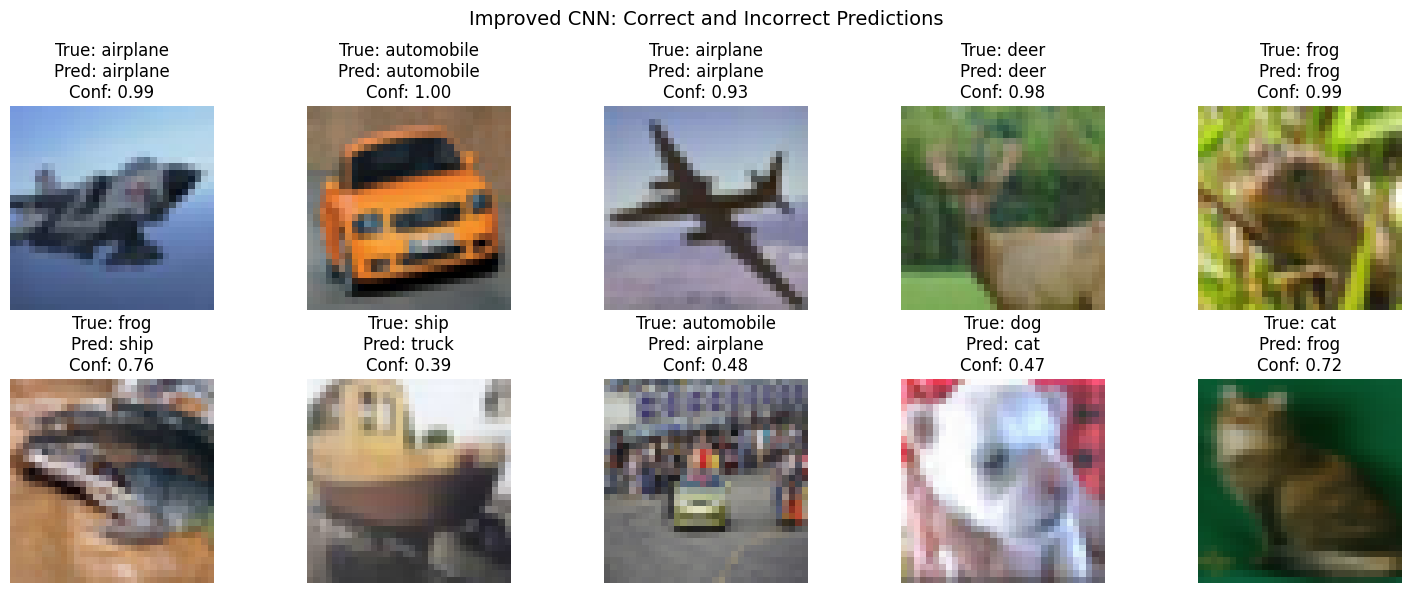

In [30]:
# Visualise correct and incorrect predictions
correct_indices = np.where(
    improved_predictions == y_test
)[0]

incorrect_indices = np.where(
    improved_predictions != y_test
)[0]

rng = np.random.default_rng(42)

selected_correct = rng.choice(
    correct_indices,
    size=5,
    replace=False
)

selected_incorrect = rng.choice(
    incorrect_indices,
    size=5,
    replace=False
)

selected_indices = np.concatenate([
    selected_correct,
    selected_incorrect
])

plt.figure(figsize=(15, 6))

for position, image_index in enumerate(selected_indices):
    plt.subplot(2, 5, position + 1)

    plt.imshow(x_test[image_index])

    true_class = class_names[y_test[image_index]]
    predicted_class = class_names[
        improved_predictions[image_index]
    ]

    confidence = improved_probabilities[
        image_index,
        improved_predictions[image_index]
    ]

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"Conf: {confidence:.2f}"
    )

    plt.axis("off")

plt.suptitle(
    "Improved CNN: Correct and Incorrect Predictions",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Conclusion

This project demonstrated how architectural design and regularisation can improve the generalisation of a Convolutional Neural Network on the CIFAR-10 image classification task.

The initial baseline CNN achieved:

- **72.57% test accuracy**
- **0.7246 macro F1-score**
- **356,810 trainable parameters**

Although the baseline learned the training data effectively, its learning curves showed clear overfitting after epoch 6.

A second CNN was therefore developed using data augmentation, additional convolutional feature extraction, batch normalisation, dropout and global average pooling.

The improved model achieved:

- **76.58% test accuracy**
- **0.7636 macro F1-score**
- **76.97% best validation accuracy**
- **141,674 total parameters**
- **+4.01 percentage points in test accuracy compared with the baseline**

Despite being substantially more compact, the improved model generalised better and reduced the overfitting observed in the baseline.

Class-level analysis showed F1-score improvements in nine of the ten categories, with particularly strong gains for cat, truck, deer, horse and automobile.

The frog class was the main exception. Its recall increased to 90.50%, but precision decreased to 60.66%, revealing that the model became overly willing to assign the frog label to visually similar animals. This demonstrates why model evaluation should extend beyond aggregate accuracy and include class-level metrics, confusion patterns and individual prediction errors.

Overall, the project shows that stronger performance does not necessarily require a larger model. A more appropriate architecture combined with regularisation and systematic error analysis produced a smaller model with better generalisation and more robust overall classification performance.